# Train smaller or finetune larger models

In [1]:
import hierarchical_binary_quantization.hbq as hbq
import hierarchical_binary_quantization.example_autoencoder_with_rope as eae
import lpips
import matplotlib.pyplot as plt
import math, random
import os
import time
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import hierarchical_binary_quantization.misc.checkpoint_helpers as ch
import hierarchical_binary_quantization.misc.dataset_helpers as dh
from datetime import datetime
from hierarchical_binary_quantization.example_autoencoder_with_rope import ExampleQuantizingAutoencoderWithRope
from hierarchical_binary_quantization.misc.checkpoint_helpers import save_checkpoint,load_checkpoint
import hierarchical_binary_quantization.example_narrow_reciptive_field_autoencoder as enrfa

from pathlib import Path
from PIL import Image
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset
from tqdm.auto import tqdm
from datetime import timedelta

dataset='fantasy'
batch_size=4
target_size=256
training_device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

#cp_path = 'checkpoints/good/2026-08-04_02:00:00finetune_256_5_bd_96_ld_32_qd_8.pth'
#cp_path = 'checkpoints/ExampleQuantizingAutoencoderWithRope_2026-09-01_22-34-06_16x16_256_5_bd_96_ld_32_qd_16.pth'
#cp_path = 'checkpoints/good/ExampleQuantizingAutoencoderWithRope_2026-09-03_06-23-04_32x32_256_4_bd_96_ld_32_qd_16.pth'
#cp_path = 'checkpoints/LocalQuantizingAutoencoder_2026-09-09_23-04-54_ps8,qd16,ld32,body:res,attn,res.pth'

cp_path = None
if False:
    cfgdict = ch.check_checkpoint(cp_path)['config']
    cfg = eae.HBQAutoencoderConfig(**cfgdict)
    print(cfg)
else:
    cfg = eae.HBQAutoencoderConfig(
        in_channels=3, 
        base_dim=96, 
        channel_multipliers=(1, 2, 3, 4), 
        res_blocks=(1, 2, 3, 3), 
        latent_dim=32, quant_dim=8, n_rounds=4
    )

cfg_32x32 = eae.HBQAutoencoderConfig(
    in_channels=3,
    base_dim=96,
    channel_multipliers=(1, 2, 3, 4),
    res_blocks=(1, 2, 3, 3),
    latent_dim=32,
    quant_dim=16,
    n_rounds=4,
    bottleneck_heads=8,
    bottleneck_layers=2,
    use_mae_aux=True,
    mae_mask_ratio=0.5,
    mae_heads=4,
    mae_depth=2,
    protected_channel_fraction=0.5,
)

cfg_16x16 = eae.HBQAutoencoderConfig(
    in_channels=3, base_dim=64, channel_multipliers=(1,2,4,4,4), res_blocks=(1,1,1,1,2),
    latent_dim=64, quant_dim=16, n_rounds=4, bottleneck_heads=8, bottleneck_layers=2,
    protected_channel_fraction=0.5, use_mae_aux=True, mae_mask_ratio=0.5, mae_heads=4, mae_depth=2,
)


cp_path = None
if cp_path:
    cfgdict = ch.check_checkpoint(cp_path)['config']
    cfg_l = eae.LocalAutoencoderConfig(**cfgdict)
    print(cfg_l)
else:
    """
    class LocalAutoencoderConfig:
    in_channels: int = 3
    stem_dim: int = 64
    stem_blocks: int = 1
    patch_size: int = 8
    body_dim: int = 256
    body: tuple = ("res", "attn")
    attn_block: int = 4
    attn_halo: int = 1
    attn_heads: int = 4
    attn_rope_base: float = 150
    latent_dim: int = 32
    quant_dim: int = 8
    n_rounds: int = 4
    refine_blocks: int = 2
    depatchify_overlap: int = 0
    use_mae_aux: bool = True
    mae_mask_ratio: float = 0.5
    mae_heads: int = 2
    mae_depth: int = 2
    """
    cfg_l8 = enrfa.LocalAutoencoderConfig( patch_size=8, body_dim=256, quant_dim=16, n_rounds=4, body = ("res", "attn", "res"), depatchify_overlap=1)
    cp_l8 = 'checkpoints/LocalQuantizingAutoencoder_2026-09-09_23-04-54_ps8,qd16,ld32,body:res,attn,res.pth'
    cfg_l16 = enrfa.LocalAutoencoderConfig( patch_size=16, body_dim=256, quant_dim=16, n_rounds=4, body = ("res", "attn", "res", "attn"))
    cfg_l16 = enrfa.LocalAutoencoderConfig(
    stem_dim=96, stem_blocks=1, patch_size=16, body_dim=256,
    body=('res','attn','res','attn'), attn_block=16, attn_halo=1, attn_heads=4,
    attn_rope_base=150, latent_dim=64, quant_dim=16, n_rounds=4, refine_blocks=2,
    depatchify_overlap=1, use_mae_aux=True, mae_mask_ratio=0.5, mae_heads=4, mae_depth=2,
)
cfg = cfg_l8

def get_autoencoder(cfg):
    global batch_size
    if isinstance(cfg,enrfa.LocalAutoencoderConfig):
        autoencoder = enrfa.LocalQuantizingAutoencoder(cfg)
        batch_size=4
    else:
        batch_size=2
        autoencoder = eae.ExampleQuantizingAutoencoderWithRope(cfg)
    return autoencoder
enrfa.receptive_field_pixels(cfg_l16)

/home/ron/proj/hierarchical-binary-quantization/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


138

In [2]:
print(ch.show_model_info(get_autoencoder(cfg)))

LocalQuantizingAutoencoder
Total parameters: 8,223,031
Trainable parameters: 8,223,031 (100.00%)

Parameter breakdown by top-level module:
decoder                             total:    4,423,044   trainable:    4,423,044   trainable%: 100.00
encoder                             total:    3,759,137   trainable:    3,759,137   trainable%: 100.00
post_quant                          total:       19,168   trainable:       19,168   trainable%: 100.00
pre_quant                           total:       19,152   trainable:       19,152   trainable%: 100.00
mae                                 total:        2,530   trainable:        2,530   trainable%: 100.00

Top 20 largest parameter tensors:
decoder.stages.2.0.weight                                    shape: (256, 64, 10, 10) params:    1,638,400  train
encoder.stages.1.0.weight                                    shape: (256, 64, 8, 8) params:    1,048,576  train
encoder.stages.2.0.net.2.weight                              shape: (256, 256, 3, 3) 

In [3]:

def show_details(cfg):
    autoencoder = get_autoencoder(cfg)
    print(cfg)
    print(f"Parameters: {sum(p.numel() for p in autoencoder.parameters())/1e6:.2f}M")

show_details(cfg_16x16)
show_details(cfg_32x32)
show_details(cfg_l16)
show_details(cfg_l8)

HBQAutoencoderConfig(in_channels=3, base_dim=64, channel_multipliers=(1, 2, 4, 4, 4), res_blocks=(1, 1, 1, 1, 2), latent_dim=64, quant_dim=16, n_rounds=4, bottleneck_heads=8, bottleneck_layers=2, protected_channel_fraction=0.5, use_mae_aux=True, mae_mask_ratio=0.5, mae_heads=4, mae_depth=2)
Parameters: 15.41M
HBQAutoencoderConfig(in_channels=3, base_dim=96, channel_multipliers=(1, 2, 3, 4), res_blocks=(1, 2, 3, 3), latent_dim=32, quant_dim=16, n_rounds=4, bottleneck_heads=8, bottleneck_layers=2, protected_channel_fraction=0.5, use_mae_aux=True, mae_mask_ratio=0.5, mae_heads=4, mae_depth=2)
Parameters: 34.21M
LocalAutoencoderConfig(in_channels=3, stem_dim=96, stem_blocks=1, patch_size=16, body_dim=256, body=('res', 'attn', 'res', 'attn'), attn_block=16, attn_halo=1, attn_heads=4, attn_rope_base=150, latent_dim=64, quant_dim=16, n_rounds=4, refine_blocks=2, depatchify_overlap=1, use_mae_aux=True, mae_mask_ratio=0.5, mae_heads=4, mae_depth=2)
Parameters: 20.72M
LocalAutoencoderConfig(in_c

In [4]:
# if resume_from_legacy_checkpoint_format := False:
#     path = 'checkpoints/legacy_finetune_256_5_bd_96_ld_32_qd_8.pth'
#     old_cp = torch.load(path,map_location='cpu')
#     autoencoder = eae.load_legacy_quant_checkpoint(autoencoder, old_cp['model_state_dict'])
#     autoencoder.eval()

def show_shapes():
    autoencoder = get_autoencoder(cfg)
        
    if cp_path:
        ch.load_checkpoint(autoencoder,None,cp_path)
    pass
    #autoencoder.to('cuda')
    #with torch.amp.autocast(device_type='cuda', dtype=torch.float16):

    imgs = torch.rand(batch_size,3,target_size,target_size)
    #imgs = torch.rand(batch_size,3,192,256)
    reconstructions, aux = autoencoder.forward(imgs)
    print(f"""
        input: {imgs.shape}
        latents: {aux.latents.shape}
        quantized: {aux.quant_info.quantized.shape}
        bit_codes: {aux.quant_info.bit_codes.shape}
        tokens: {aux.quant_info.tokens is not None and aux.quant_info.tokens.shape}
        reconstructions: {reconstructions.shape}
        """)

show_shapes()
    


        input: torch.Size([4, 3, 256, 256])
        latents: torch.Size([4, 32, 32, 32])
        quantized: torch.Size([4, 16, 32, 32])
        bit_codes: torch.Size([4, 16, 32, 32])
        tokens: False
        reconstructions: torch.Size([4, 3, 256, 256])
        


## Dataset config

In [5]:
# class ImageDataset(Dataset):
#     def __init__(self, root, transform=None):
#         self.transform = transform
#         exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")
#         self.files = []
#         for ext in exts:
#             self.files.extend(Path(root).rglob(ext))
#         self.files = sorted(self.files)
#         print(f"Found {len(self.files)} images.")

#     def __len__(self):
#         return len(self.files)

#     def __getitem__(self, idx):
#         img = Image.open(self.files[idx]).convert("RGB")
#         if self.transform:
#             img = self.transform(img)
#         return img

# transform = transforms.Compose([
#     transforms.Resize(target_size),
#     transforms.RandomHorizontalFlip(),
#     transforms.ToTensor(),
#     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
# ])

import io
class ImageDataset(Dataset):
    def __init__(self, blob_ds, transform=None):
        self.transform = transform
        self.blob_ds = blob_ds

    def __len__(self):
        return len(self.blob_ds)

    def __getitem__(self, idx):
        id, data, md = self.blob_ds[idx]
        img = Image.open(io.BytesIO(data)).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img

transform = transforms.Compose([
    dh.PadToRectangle(384,512),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
bds = dh.BlobDataset("data/fantasy_384x512.sqlite3","r")

imgds = ImageDataset(bds, transform)
next(iter(imgds))
imgds[10]
from hierarchical_binary_quantization.misc.image_helpers import tensor_to_pil
tensor_to_pil(imgds[10])
import io


def get_dataset_and_loader(dataset):
    train_dataset = ImageDataset(bds, transform)
    batch_size=1
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
    )
    return train_dataset,train_loader
train_dataset,train_loader = get_dataset_and_loader(dataset)
print(f"{len(train_dataset)} training images")
next(iter(train_loader)).shape

11178 training images


torch.Size([1, 3, 512, 384])

In [6]:
import matplotlib.pyplot as plt
import torch
from PIL import Image
import numpy as np
import hierarchical_binary_quantization.misc.image_helpers as ih
import IPython.display as ipd

def show_reconstructions(model, imgs):
    was_training = model.training
    model.eval()
    with torch.inference_mode():
        reconstructions, aux = model(imgs[:1])
    if was_training:
        model.train()
    original = ih.tensor_to_pil(imgs[0])
    reconstruction = ih.tensor_to_pil(reconstructions[0])
    latent = ih.tensor_to_pil(ih.q_out_to_rgb(aux.quant_info.quantized)[0])
    if aux.quant_info.tokens is not None:
        unique = aux.quant_info.tokens.unique().numel()
        print(
            f"unique tokens={unique} out of "
            f"{2**(aux.quant_info.n_rounds * model.config.quant_dim)}."
        )

    with torch.inference_mode():
        # real quantized codes everywhere except the masked spots, where we
        # substitute the predictor's guess -- so a bad fill only ever shows up
        # as a bad fill, not compounded with untrained noise everywhere else.
        composite = aux.mae_mask * aux.mae_pred + (1 - aux.mae_mask) * aux.quant_info.quantized
        mae_lat = autoencoder.post_quant(composite)
        # mae_out = autoencoder.backbone.decode(mae_lat)  # The global attention one
        mae_out = autoencoder.decode(mae_lat)

        #mae_out = (mae_out / 2 + 0.5).clamp(0, 1)
        mae_img = ih.tensor_to_pil(mae_out.cpu()[0])
    h = ih.html_for_images([original, latent, reconstruction, mae_img],min_height=256)    
    return h, original, latent, reconstruction

# imgs = next(iter(train_loader)).to('cpu')
# h,*i2 = show_reconstructions(autoencoder, imgs)
# ipd.display(ipd.HTML(h))


## Train The Model

In [7]:
from torchmetrics.image import PeakSignalNoiseRatio
psnr_metric = PeakSignalNoiseRatio(data_range=(-1.0,1.0))  # verify this matches your actual range first


In [15]:
### Prep for training

autoencoder = get_autoencoder(cfg)
cp_path = cp_l8
if resume:=cp_path:
    good_checkpoint = cp_path
    #cfg = ch.check_checkpoint(good_checkpoint)['config']
    #autoencoder = eae.ExampleQuantizingAutoencoderWithRope(**cfg)
    ch.load_checkpoint(autoencoder,None,good_checkpoint,strict=False)




🔄 Loading checkpoint from checkpoints/LocalQuantizingAutoencoder_2026-09-09_23-04-54_ps8,qd16,ld32,body:res,attn,res.pth
    Model class: LocalQuantizingAutoencoder
{'in_channels': 3, 'stem_dim': 64, 'stem_blocks': 1, 'patch_size': 8, 'body_dim': 256, 'body': ('res', 'attn', 'res'), 'attn_block': 4, 'attn_halo': 1, 'attn_heads': 4, 'attn_rope_base': 150, 'latent_dim': 32, 'quant_dim': 16, 'n_rounds': 4, 'refine_blocks': 2, 'depatchify_overlap': 1, 'use_mae_aux': True, 'mae_mask_ratio': 0.5, 'mae_heads': 2, 'mae_depth': 2}


In [16]:
quantizer = hbq.QuantizerRandomizer([
    hbq.HBQQuantizer(n_rounds=1),
    hbq.HBQQuantizer(n_rounds=2),
    hbq.HBQQuantizer(n_rounds=3),
    hbq.HBQQuantizer(n_rounds=3),
    hbq.HBQQuantizer(n_rounds=4),
    hbq.HBQQuantizer(n_rounds=4),
])

autoencoder.quantizer = quantizer

# quant_dim=8, n_rounds = 4 = 32 bits

autoencoder.to(training_device)
optimizer = torch.optim.AdamW(
    autoencoder.parameters(),
    lr=1e-4, # 3e-4 often fails to converge on Cats&Dogs dataset (mostly brown; local minima of all brown images can be found with huge weights)
    weight_decay=1e-4,
)

if cp_path:
    ch.load_checkpoint(autoencoder, optimizer, cp_path, strict=True)

print(autoencoder.config)
print(
    f"Parameters: {sum(p.numel() for p in autoencoder.parameters())/1e6:.2f}M"
)


🔄 Loading checkpoint from checkpoints/LocalQuantizingAutoencoder_2026-09-09_23-04-54_ps8,qd16,ld32,body:res,attn,res.pth
    Model class: LocalQuantizingAutoencoder
{'in_channels': 3, 'stem_dim': 64, 'stem_blocks': 1, 'patch_size': 8, 'body_dim': 256, 'body': ('res', 'attn', 'res'), 'attn_block': 4, 'attn_halo': 1, 'attn_heads': 4, 'attn_rope_base': 150, 'latent_dim': 32, 'quant_dim': 16, 'n_rounds': 4, 'refine_blocks': 2, 'depatchify_overlap': 1, 'use_mae_aux': True, 'mae_mask_ratio': 0.5, 'mae_heads': 2, 'mae_depth': 2}
LocalAutoencoderConfig(in_channels=3, stem_dim=64, stem_blocks=1, patch_size=8, body_dim=256, body=('res', 'attn', 'res'), attn_block=4, attn_halo=1, attn_heads=4, attn_rope_base=150, latent_dim=32, quant_dim=16, n_rounds=4, refine_blocks=2, depatchify_overlap=1, use_mae_aux=True, mae_mask_ratio=0.5, mae_heads=2, mae_depth=2)
Parameters: 8.22M


In [17]:
import torch.nn.functional as F
def color_difference_loss(pred, target):
    return (
        F.l1_loss(pred[:,0]-pred[:,1], target[:,0]-target[:,1]) +
        F.l1_loss(pred[:,0]-pred[:,2], target[:,0]-target[:,2]) +
        F.l1_loss(pred[:,1]-pred[:,2], target[:,1]-target[:,2])
    )


In [18]:
import mlflow
from mlflow.tracking import MlflowClient

# uv run mlflow ui --backend-store-uri sqlite:///mlflow.db
class MLFlowHelper:

    def __init__(self, experiment_name, loggable_params,run_name=None):

        self.experiment_name = experiment_name
        self.run_name = run_name
        self.loggable_params = loggable_params
        self.logged_step = 0
        mlflow.set_tracking_uri("sqlite:///mlflow.db")
        mlflow.set_experiment(self.experiment_name)

        from dataclasses import asdict,is_dataclass
        
        if is_dataclass(loggable_params):
            loggable_params = asdict(loggable_params)

        if run_name is None:
            with mlflow.start_run() as run:
                self.run_name = run.info.run_name
                self.run_id = run.info.run_id

        self.run_id = self.get_mflow_run_id()
        if not self.run_id:
            with mlflow.start_run(run_name=self.run_name):
                pass
            self.run_id = self.get_mflow_run_id()

        with mlflow.start_run(run_id=self.run_id):
            for k,v in loggable_params.items():
                mlflow.log_param(k,v)  

    def get_mflow_run_id(self):
        runs = mlflow.search_runs(
            experiment_names=[self.experiment_name],
            filter_string=f"attributes.run_name = '{self.run_name}'"
        )

        if not runs.empty:
            mlflow_run_id = runs.iloc[0]["run_id"]
            print(f"Found existing run: {mlflow_run_id}. Resuming...")
            return mlflow_run_id
        else:
            print(f"No existing run found with run_name {self.run_name}.")
            return None

    def log_to_mlflow(self, mlflow_step, metrics):
        with mlflow.start_run(run_id=self.run_id):
            for k,v in metrics.items():
                mlflow.log_metric(k, v, step=mlflow_step)


# for i in range(3):
#     mfh.log_to_mlflow(i, {"elapsed_seconds":1,"samples_per_second":1,"loss":1})
# mlflow.end_run()

In [19]:

import torch
import time
from tqdm import tqdm
import torch.nn.functional as F

def train_some(autoencoder, optimizer, train_loader, device, 
               continued_training_elapsed_time=0,
               continued_training_item_counter=0,
               epochs=1_000_000,grad_checkpointing=False,
               max_training_time = 60 * 60 * 24 * 7,
               exp_name="hbq", run_name=None, tag = None
              ):

    ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    tsm = datetime.now().strftime("%Y-%m-%d_%H-%M")
    cfg = autoencoder.config
    cls_name = autoencoder.__class__.__name__
    if isinstance(cfg,enrfa.LocalAutoencoderConfig):
        cls_nickname="LAE"
        tag = tag or f"ps{cfg.patch_size},qd{cfg.quant_dim},ld{cfg.latent_dim},sd{cfg.stem_dim},body:{",".join(cfg.body)}"
    elif isinstance(cfg,eae.HBQAutoencoderConfig):
        cls_nickname="EAE"
        ps = 256/(2**(len(cfg.channel_multipliers)-1))
        cms = ",".join([str(x) for x in cfg.channel_multipliers])
        tag = tag or f"ps{ps},qd{cfg.quant_dim},cm:{cms}"
    else:
        cls_nickname=cls_name
    
    run_name = run_name or f"{cls_nickname}_{tag}"
    cp_path = f"checkpoints/{cls_nickname}_{ts}_{tag}.pth"

    mfh = MLFlowHelper(exp_name,cfg,run_name)
    output_file = f"outputs/{exp_name}_{ts}_{cls_nickname}_{tag}.html"

    with open(output_file,"a") as f:
        f.write(f"<h2>{cls_name}</h2><br>")
        f.write(f"<pre>{str(autoencoder.config)}</pre><br>")
        f.write(
                    f"Parameters: {sum(p.numel() for p in autoencoder.parameters())/1e6:.2f}M"
                )
        f.write(f"<pre>{str(ch.show_model_info(autoencoder))}</pre><br>")
    autoencoder.to(device)
    #autoencoder.set_grad_checkpointing(grad_checkpointing)

    loss_history = []
    t0 = time.time()
    item_counter = 0
    display_interval = 1
    next_display = t0 + display_interval
    loss_fn = lpips.LPIPS(net='vgg').eval().requires_grad_(False).to(device)    
    
    scaler = torch.amp.GradScaler('cuda')
    
    for epoch in range(epochs):
        if time.time() - t0 > max_training_time:
            break
        autoencoder.train()
        running_loss = 0.0
        progress = tqdm(train_loader)
        for imgs in progress:
            if time.time() - t0 > max_training_time:
                break

            imgs = imgs.to(device)
            optimizer.zero_grad()
            batch_size = imgs.shape[0]
            item_counter += batch_size
            with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                recon, aux = autoencoder(imgs)
                loss_lpips = loss_fn(recon, imgs).sum()
                loss_l1 = F.l1_loss(recon, imgs)
                loss_color = color_difference_loss(recon, imgs)
                loss_mae = aux.mae_loss()
                #loss_mse = F.mse_loss(recon,imgs) # worse than l1 for autoencoders
                psnr = psnr_metric(recon.clone().detach().cpu(),imgs.clone().detach().cpu())
                loss = (loss_l1 + 2.0 * loss_lpips + 0.5 * loss_color + loss_mae * 0.25)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        
            running_loss += loss.item()
            progress.set_description(f"Epoch {epoch+1}/{epochs} {loss.item():.3f}")
            
            if time.time() > next_display:
                total_training_time = time.time() - t0 + continued_training_elapsed_time
                next_display = time.time() + display_interval
                display_interval = min(1.2*display_interval, 60*30)

                loggable_params = {
                    "loss":loss.item(),
                    "loss_l1":loss_l1.item(),
                    "loss_lpips":loss_lpips.item(),
                    "loss_color": loss_color.item(),
                    "loss_mae": loss_mae.item(),
                    "items":continued_training_item_counter + item_counter,
                    "latent_μ":aux.latents.mean().item(),
                    "latent_σ": aux.latents.std().item(),
                    "psnr": psnr,
                }
                mfh.log_to_mlflow(total_training_time//60, loggable_params)
                def nicev(v):
                    return f"{v:.3f}" if isinstance(v,float) else f"{v}"
                info =(
                    f"time={str(timedelta(seconds=total_training_time))} " +
                    " ".join([f"{k}:{nicev(v)} " for k,v in loggable_params.items()])
                )

                h, *imgs_show = show_reconstructions(autoencoder, imgs)
                #debug_latent_correlations(aux.latents)
                with open(output_file,"a") as f:
                    f.write(info)
                    f.write(h)
                ipd.clear_output(wait=True)
                print(info)
                ipd.display(ipd.HTML(h))
    
        epoch_loss = running_loss / len(train_loader)
        loss_history.append(epoch_loss)
        print(f"Epoch {epoch+1:2d}: {epoch_loss:.6f}")

In [20]:
import torch
torch.cuda.is_available()

True

time=6:56:24.473237 loss:0.160  loss_l1:0.024  loss_lpips:0.046  loss_color:0.035  loss_mae:0.107  items:92597  latent_μ:-0.280  latent_σ:2.811  psnr:32.81003189086914 



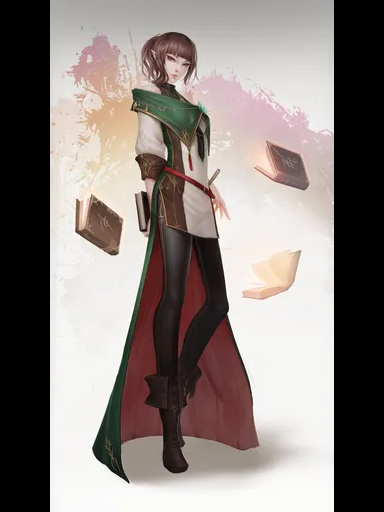
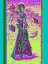
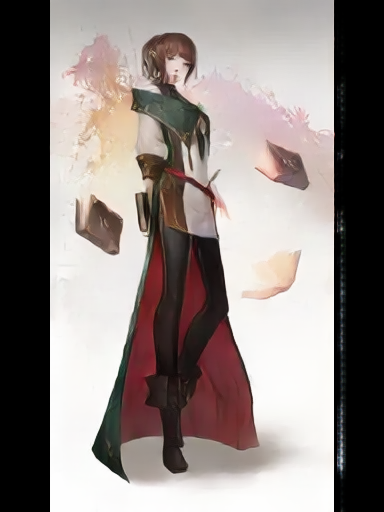
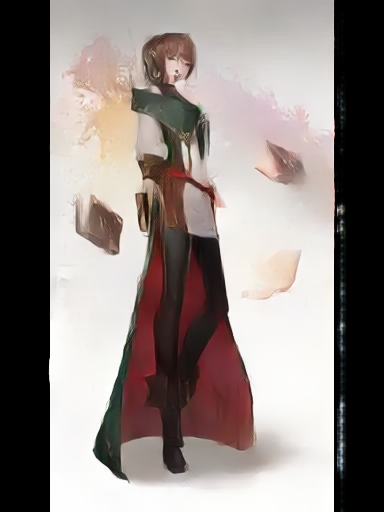

Epoch 9/1000000 0.125:  30%|███       | 3390/11178 [15:11<34:53,  3.72it/s]

Done


In [21]:


try:
    autoencoder.mae.mask_ratio = 0.25
    train_some(autoencoder, optimizer, train_loader,device=training_device,max_training_time=8*60*60)
except KeyboardInterrupt as e:
    autoencoder.zero_grad(set_to_none=True)
    print("Done")


In [22]:
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
cls_name = autoencoder.__class__.__name__
tag = f"ps{cfg.patch_size},qd{cfg.quant_dim},ld{cfg.latent_dim},body:{",".join(cfg.body)}"
path = f"checkpoints/{cls_name}_{timestamp}_{tag}.pth"
save_checkpoint(autoencoder,path,optimizer=optimizer)

✅ Saved checkpoint: checkpoints/LocalQuantizingAutoencoder_2026-09-12_07-44-00_ps8,qd16,ld32,body:res,attn,res.pth


'checkpoints/LocalQuantizingAutoencoder_2026-09-12_07-44-00_ps8,qd16,ld32,body:res,attn,res.pth'

In [ ]:
#!cp 'checkpoints/LocalQuantizingAutoencoder_2026-09-12_07-44-00_ps8,qd16,ld32,body:res,attn,res.pth' checkpoints/good/reallygood_LocalQuantizingAutoencoder_2026-09-12_07-44-00_ps8,qd16,ld32,body:res,attn,res.pth


In [25]:
# A good 8x8 patch size model
path = 'checkpoints/good/reallygood_LocalQuantizingAutoencoder_2026-09-12_07-44-00_ps8,qd16,ld32,body:res,attn,res.pth'
a2 = ch.create_from_checkpoint(enrfa.LocalQuantizingAutoencoder,path)

🔄 Loading checkpoint from checkpoints/good/reallygood_LocalQuantizingAutoencoder_2026-09-12_07-44-00_ps8,qd16,ld32,body:res,attn,res.pth with {'in_channels': 3, 'stem_dim': 64, 'stem_blocks': 1, 'patch_size': 8, 'body_dim': 256, 'body': ('res', 'attn', 'res'), 'attn_block': 4, 'attn_halo': 1, 'attn_heads': 4, 'attn_rope_base': 150, 'latent_dim': 32, 'quant_dim': 16, 'n_rounds': 4, 'refine_blocks': 2, 'depatchify_overlap': 1, 'use_mae_aux': True, 'mae_mask_ratio': 0.5, 'mae_heads': 2, 'mae_depth': 2}


In [26]:
# quantizer = hbq.QuantizerRandomizer([
#     hbq.HBQQuantizer(n_rounds=1),
#     hbq.HBQQuantizer(n_rounds=2),
#     hbq.HBQQuantizer(n_rounds=3),
#     hbq.HBQQuantizer(n_rounds=4),
# ])

# autoencoder.quantizer = quantizer

# # quant_dim=8, n_rounds = 4 = 32 bits

# autoencoder.to(training_device)
# optimizer = torch.optim.AdamW(
#     autoencoder.parameters(),
#     lr=1e-4, # 3e-4 often fails to converge on Cats&Dogs dataset (mostly brown; local minima of all brown images can be found with huge weights)
#     weight_decay=1e-4,
# )

# try:
#     autoencoder.mae.mask_ratio = 0.5
#     train_some(autoencoder, optimizer, train_loader,device=training_device,max_training_time=7*60*60)
# except KeyboardInterrupt as e:
#     autoencoder.zero_grad(set_to_none=True)
#     print("Done")


In [27]:
!ls -lh {path}
#!cp {path} checkpoints/good


-rw-rw-r-- 1 ron ron 16M Sep 12 07:44 checkpoints/good/reallygood_LocalQuantizingAutoencoder_2026-09-12_07-44-00_ps8,qd16,ld32,body:res,attn,res.pth


In [28]:
def debug_latent_correlations(latent):
    with torch.no_grad():
        z = latent  # (B,C,H,W), BEFORE tanh
        # One row per channel, one column per sample/pixel
        x = z.permute(1, 0, 2, 3).reshape(z.shape[1], -1)
        # Center each channel
        x = x - x.mean(dim=1, keepdim=True)
        # Normalize each channel to unit variance
        x = x / (x.std(dim=1, keepdim=True) + 1e-8)
        # Correlation matrix
        corr = (x @ x.T) / x.shape[1]
        print("Channel correlation:")
        print(corr.cpu().numpy().round(2))
        offdiag = corr - torch.eye(corr.shape[0], device=corr.device)
        mean_abs_corr = offdiag.abs().sum() / (corr.numel() - corr.shape[0])
        print(f"Mean |off-diagonal correlation| = {mean_abs_corr:.3f}")
with torch.no_grad():
    autoencoder.to('cpu')
    i,aux = autoencoder(next(iter(train_loader)).to('cpu'))
# A suggestion from ChatGPT to debug if color was bottlenecked before the quantizer.
print(aux.latents.shape, aux.quant_info.quantized.shape, aux.quant_info.tokens is not None and aux.quant_info.tokens.shape)
debug_latent_correlations(autoencoder.pre_quant(aux.latents))

torch.Size([1, 32, 64, 48]) torch.Size([1, 16, 64, 48]) False
Channel correlation:
[[ 1.   -0.61 -0.27 -0.66  0.38 -0.05 -0.59  0.61  0.48  0.38  0.63 -0.46
   0.46  0.66 -0.09  0.54]
 [-0.61  1.    0.31  0.48 -0.35 -0.23  0.64 -0.6  -0.66 -0.41 -0.47  0.36
  -0.7  -0.55  0.09 -0.34]
 [-0.27  0.31  1.    0.15 -0.39  0.03  0.43 -0.4  -0.38 -0.05 -0.16  0.01
  -0.27 -0.31  0.07 -0.27]
 [-0.66  0.48  0.15  1.   -0.27  0.03  0.54 -0.59 -0.41 -0.43 -0.66  0.45
  -0.44 -0.56  0.04 -0.39]
 [ 0.38 -0.35 -0.39 -0.27  1.   -0.11 -0.4   0.4   0.43  0.1   0.29 -0.1
   0.36  0.32 -0.21  0.31]
 [-0.05 -0.23  0.03  0.03 -0.11  1.   -0.03 -0.04  0.12  0.01 -0.07 -0.07
   0.27 -0.07 -0.15 -0.18]
 [-0.59  0.64  0.43  0.54 -0.4  -0.03  1.   -0.73 -0.67 -0.45 -0.59  0.25
  -0.54 -0.55 -0.04 -0.47]
 [ 0.61 -0.6  -0.4  -0.59  0.4  -0.04 -0.73  1.    0.66  0.45  0.58 -0.37
   0.52  0.53 -0.04  0.5 ]
 [ 0.48 -0.66 -0.38 -0.41  0.43  0.12 -0.67  0.66  1.    0.33  0.42 -0.21
   0.56  0.42 -0.05  0.35]
 [ 0.38 -

In [ ]:
# !cp checkpoints/ExampleQuantizingAutoencoder_2026-08-04_23-40-17_finetune_256_4_bd_96_ld_32_qd_8.pth checkpoints/good/2026-08-04_23-41-00_256_4_bd_96_ld_32_qd_8.pth
# !ls -l checkpoints/good


In [ ]:
# import importlib
# import hierarchical_binary_quantization.example_autoencoder_with_rope as eae
# import hierarchical_binary_quantization
# import hierarchical_binary_quantization.misc.checkpoint_helpers as ch
# importlib.reload(eae)
# importlib.reload(hierarchical_binary_quantization)
# good_checkpoint = cp_path 
# cfg = ch.check_checkpoint(good_checkpoint)['config']
# autoencoder = eae.ExampleQuantizingAutoencoderWithRope(**cfg)
# ch.load_checkpoint(autoencoder,None,good_checkpoint)


In [30]:
import torch
with torch.no_grad():
    autoencoder.cpu()
    autoencoder.quantizer = hbq.HBQQuantizer(n_rounds=1)
    i,aux = autoencoder(next(iter(train_loader)))

aux.quant_info.tokens.cpu()[0]
histogram = torch.bincount(aux.quant_info.tokens.cpu()[0].flatten())
histogram.shape

torch.Size([65499])


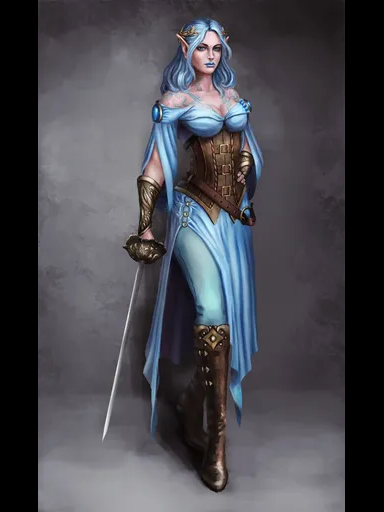
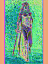
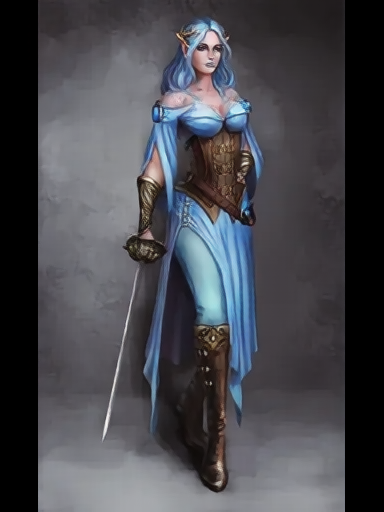
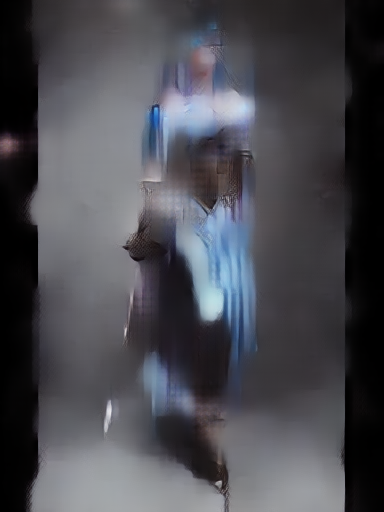

In [35]:
train_dataset,train_loader = get_dataset_and_loader("pokemon")

imgs = next(iter(train_loader))
autoencoder.mae.mask_ratio=0.8
autoencoder.quantizer = hbq.HBQQuantizer(n_rounds=8)
h,*i2 = show_reconstructions(autoencoder, imgs.to('cpu'))
ipd.HTML(h)

In [ ]:
cfg

LocalAutoencoderConfig(in_channels=3, stem_dim=64, stem_blocks=1, patch_size=16, body_dim=256, body=('res', 'attn'), attn_block=4, attn_halo=1, attn_heads=4, attn_rope_base=150, latent_dim=32, quant_dim=16, n_rounds=4, refine_blocks=2, depatchify_overlap=0, use_mae_aux=True, mae_mask_ratio=0.5, mae_heads=2, mae_depth=2)

dict_keys(['orig', 1, 'mae1', 2, 'mae2', 3, 'mae3', 4, 'mae4', 'inf'])
psnrs by round {'inf': 31.022735595703125, 1: 27.382442474365234, 2: 29.786922454833984, 3: 30.68488311767578, 4: 31.022735595703125}



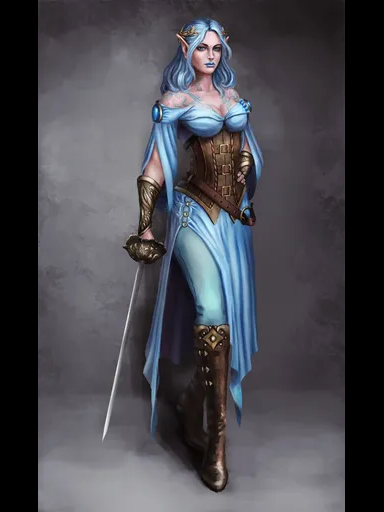
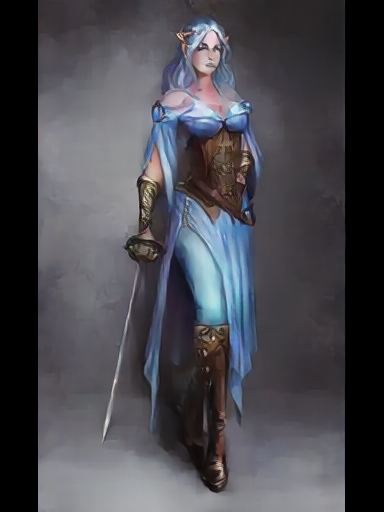
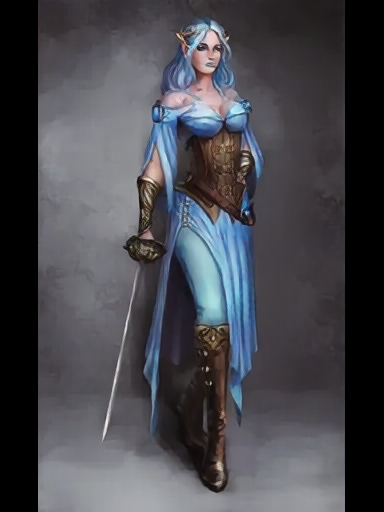
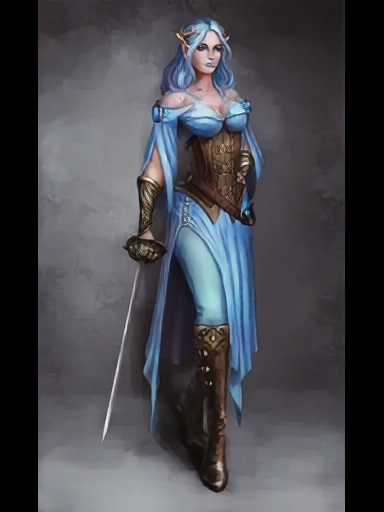
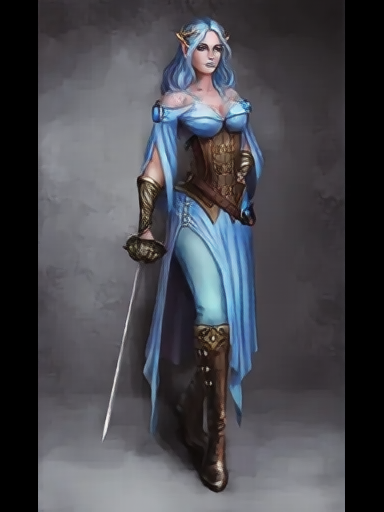
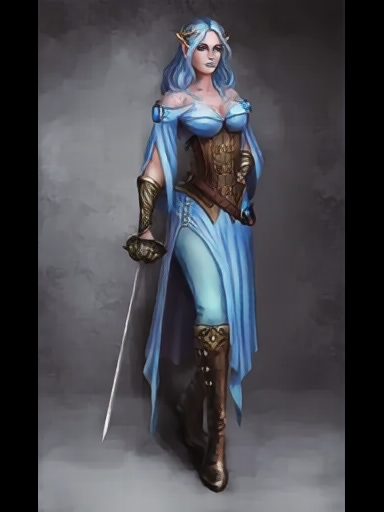
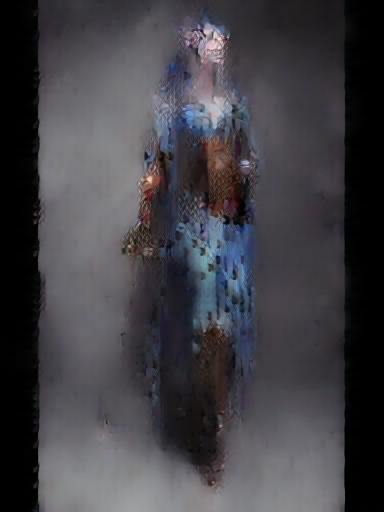
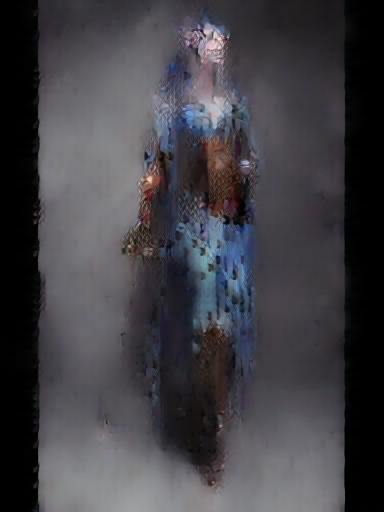

In [36]:
from hierarchical_binary_quantization.hbq import (
    bit_codes_to_tokens, tokens_to_bit_codes, bit_codes_to_quantized_latent,
)
@torch.inference_mode()
def decode_all_levels(autoencoder, imgs, max_rounds=4):
    """bit_codes: (B, L, H, W) int, full-resolution accumulated codes.
    Returns {round: images (B, C, H, W) in [0,1]} for round in 1..max_rounds."""
    with torch.inference_mode():
        reconstructions, aux = autoencoder(imgs[:1])

    latents = aux.latents
    bit_codes = aux.quant_info.bit_codes
    original = imgs[0].detach().cpu().permute(1,2,0)
    results = {}
    results['orig'] = original
    psnrs={}
    psnrs['inf'] = psnr_metric(imgs[:1].cpu(),reconstructions[:1].cpu()).item()

    for r in range(1, max_rounds + 1):
        r_bits = bit_codes >> (max_rounds - r)                    # (B, L, H, W)
        r_bits = r_bits.permute(0, 2, 3, 1)                        # (B, H, W, L)
        quantized = bit_codes_to_quantized_latent(r_bits, n_rounds=r)
        quantized = quantized.permute(0, 3, 1, 2).contiguous()     # (B, L, H, W)
        z = autoencoder.post_quant(quantized)
        images = autoencoder.decode(z)
        results[r] = images.cpu()

        psnrs[r] = psnr_metric(images.cpu(),imgs[:1].cpu()).item()

        z2 = autoencoder.post_quant(aux.mae_pred)
        images2 = autoencoder.decode(z2)
        results[f"mae{r}"] = images2.cpu()
        
    if True:
        inf = autoencoder.decode(autoencoder.post_quant(autoencoder.pre_quant(latents)))
        results['inf'] = inf.cpu()
    return results,psnrs
autoencoder.quantizer = hbq.HBQQuantizer(n_rounds=4)
autoencoder.mae.mask_ratio = 0.5
levels,psnrs = decode_all_levels(autoencoder,imgs)
print(levels.keys())
all_imgs = [
    levels['orig'], levels[1][0], levels[2][0], levels[3][0], levels[4][0], levels['inf'][0],
    levels["mae1"][0],levels["mae4"][0],
    ]
titles = ["original","round1", "round2", "round3", "round4", "round infinity"]
print("psnrs by round", psnrs)
#psnrs = [psnrs[i] for i in [1,2,3,4,'inf']]
zimgs = [ih.tensor_to_pil(i) for i in all_imgs]
ipd.display(ipd.HTML(ih.html_for_images(zimgs, title=" / ".join(titles), min_height=128)))


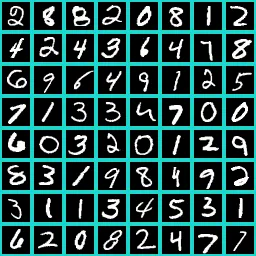
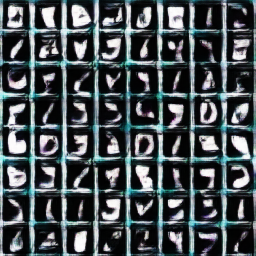
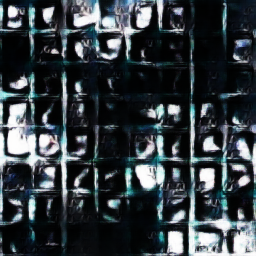

In [ ]:
autoencoder.mae.mask_ratio = 0.4
h, *imgs_show = show_reconstructions(autoencoder, imgs)
#debug_latent_correlations(aux.latents)
ipd.display(ipd.HTML(h))


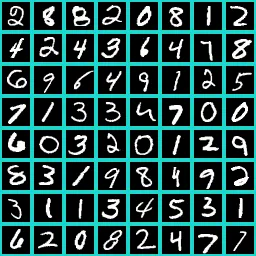
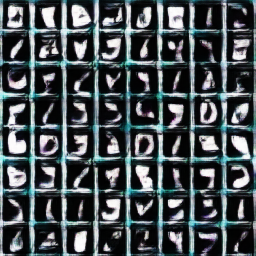
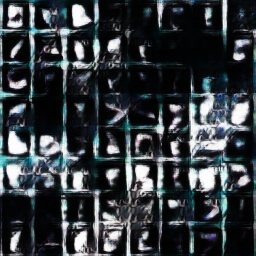

In [ ]:
autoencoder.mae.mask_ratio = 0.3
h, *imgs_show = show_reconstructions(autoencoder, imgs)
#debug_latent_correlations(aux.latents)
ipd.display(ipd.HTML(h))


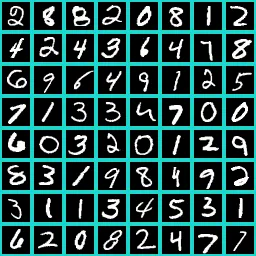
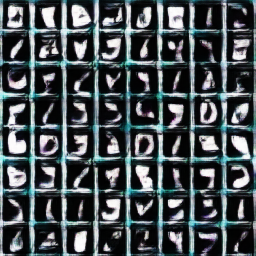
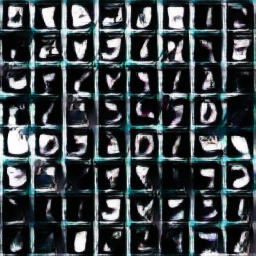

In [ ]:
autoencoder.mae.mask_ratio = 0.1
h, *imgs_show = show_reconstructions(autoencoder, imgs)
#debug_latent_correlations(aux.latents)
ipd.display(ipd.HTML(h))


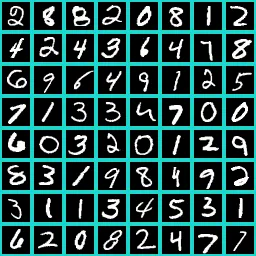
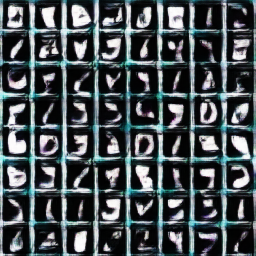
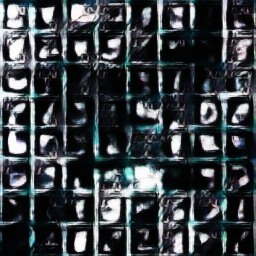

In [ ]:
autoencoder.mae.mask_ratio = 0.3
h, *imgs_show = show_reconstructions(autoencoder, imgs)
#debug_latent_correlations(aux.latents)
ipd.display(ipd.HTML(h))